# Dataset 2 Analysis: KaraOne


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'eeg_dataset_analysis_lib.py').exists():
            return candidate
    raise RuntimeError('Could not locate project root containing scripts/eeg_dataset_analysis_lib.py')

PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
from eeg_dataset_analysis_lib import analyze_karaone


In [2]:
bundle = analyze_karaone()
summary = bundle.summary
assets = bundle.assets
summary['dataset_name'], summary['downloaded_archive_count']

Reading 0 ... 16572  =      0.000 ...    16.572 secs...


('KaraOne', 14)

## 一、数据集整体概览

In [3]:
archive_df = pd.DataFrame(summary['archive_rows'], columns=['subject_archive', 'size_gb'])
display(archive_df)
display(Markdown(f"- representative subject: `{summary['representative_subject']}`"))
display(Markdown(f"- sampling rate: `{summary['sampling_rate_hz']}` Hz"))
display(Markdown(f"- raw duration: `{summary['raw_duration_sec'] / 60:.2f}` minutes"))


,subject_archive,size_gb
0,MM05,2.04
1,MM08,2.24
2,MM09,1.57
3,MM10,1.67
4,MM11,1.83
5,MM12,2.11
6,MM14,2.08
7,MM15,1.18
8,MM16,1.21
9,MM18,1.22


- representative subject: `MM05`

- sampling rate: `1000.0` Hz

- raw duration: `41.29` minutes

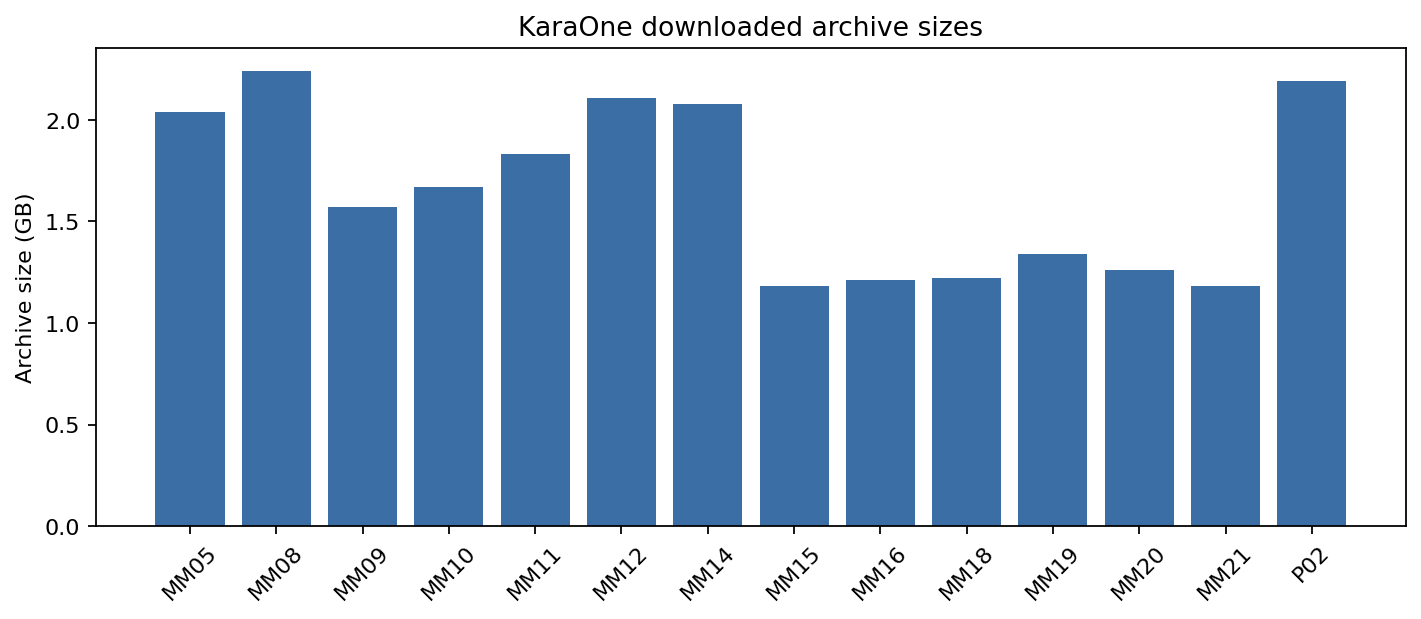

In [4]:
display(Image(filename=assets['archive_sizes']))

## 二、实验范式分析

In [5]:
interval_df = pd.DataFrame([
    ['clearing', summary['clearing_interval_count'], summary['clearing_duration_mean_sec']],
    ['thinking', summary['thinking_interval_count'], summary['thinking_duration_mean_sec']],
    ['stimulus_like', summary['stimulus_like_interval_count'], summary['stimulus_like_duration_mean_sec']],
    ['overt_like', summary['overt_like_interval_count'], summary['overt_like_duration_mean_sec']],
], columns=['interval_family', 'count', 'mean_duration_sec'])
display(interval_df)
display(Markdown('`epoch_inds.mat` 明确给出了 clearing / thinking / speaking-like 区间；结合标签与 wav，可以把 speaking-like 再拆成 stimulus-like 与 overt-like 两段。'))


,interval_family,count,mean_duration_sec
0,clearing,165,4.978442
1,thinking,165,4.949630
2,stimulus_like,165,2.008121
3,overt_like,165,2.354024


`epoch_inds.mat` 明确给出了 clearing / thinking / speaking-like 区间；结合标签与 wav，可以把 speaking-like 再拆成 stimulus-like 与 overt-like 两段。

## 三、单受试者深度分析

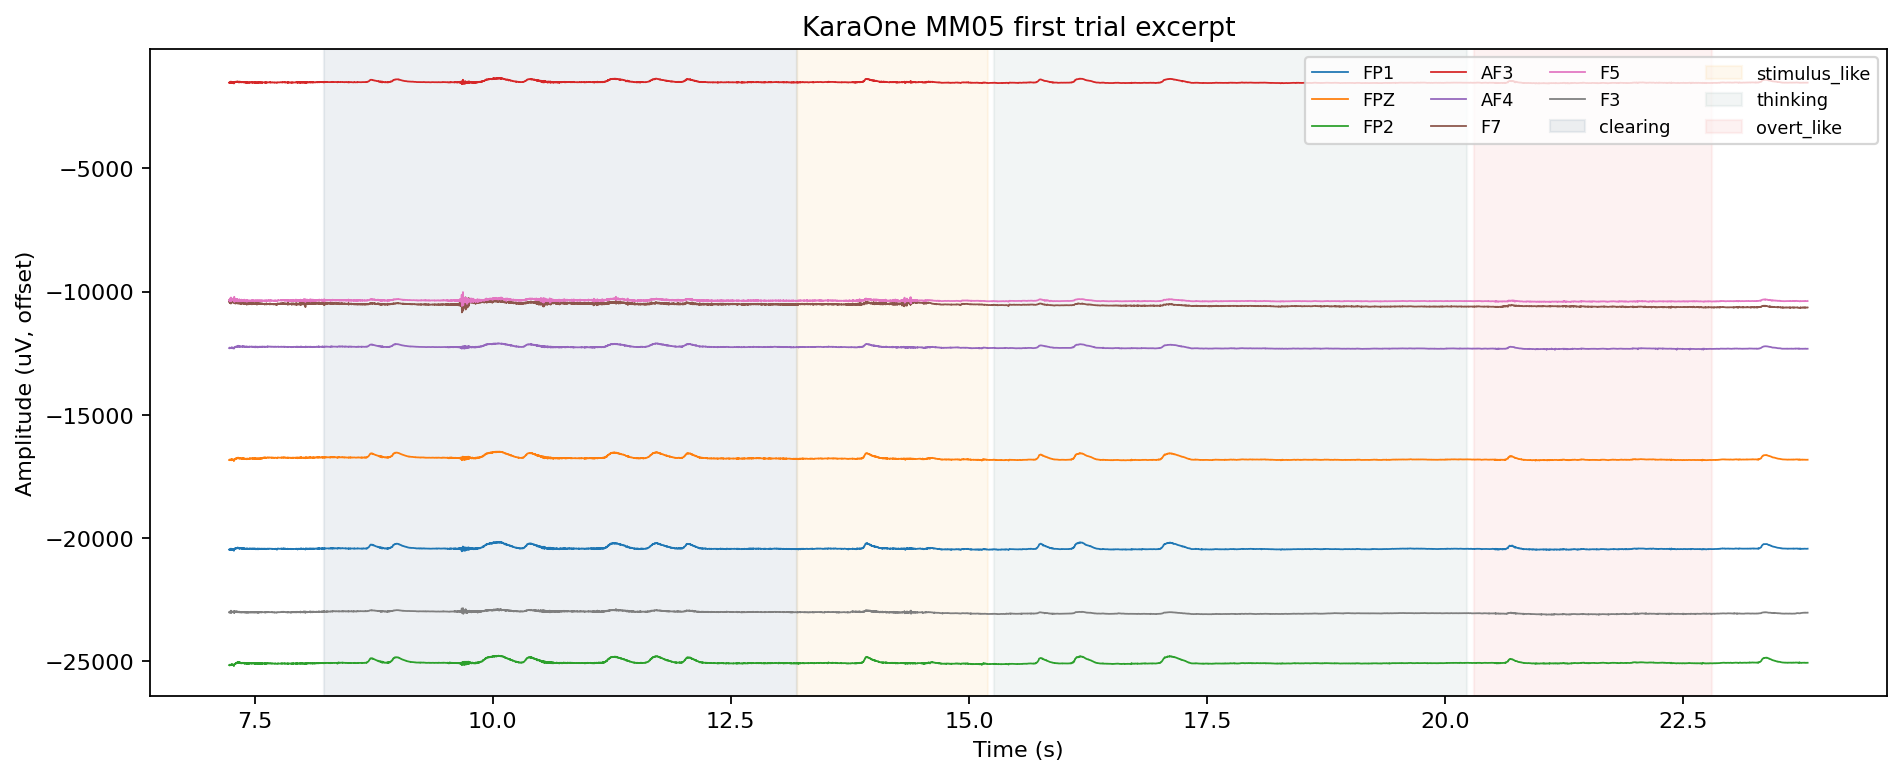

In [6]:
display(Image(filename=assets['waveform']))

clearing：清空上一 trial 的残留状态
thinking：在脑中默念/想象目标语音
stimulus-like：接收或确认当前 prompt
overt-like：真正说出该 prompt

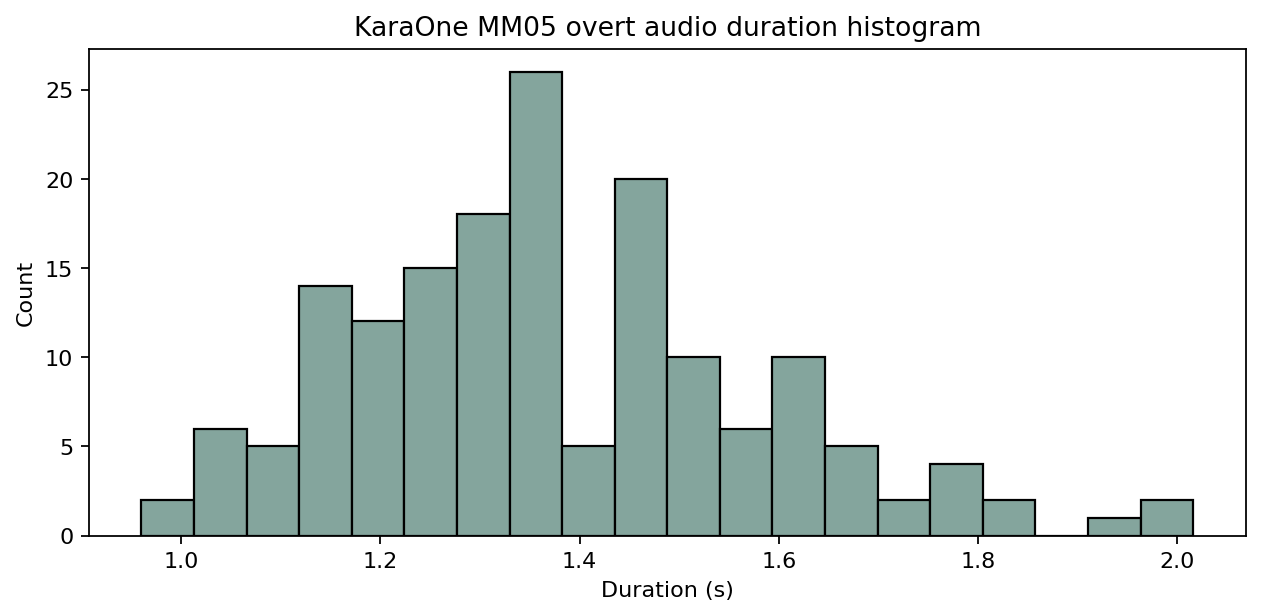

In [7]:
display(Image(filename=assets['audio_durations']))

## 四、事件与标签分析

,label,count
0,/diy/,15
1,/iy/,15
2,/m/,15
3,/n/,15
4,/piy/,15
5,/tiy/,15
6,/uw/,15
7,gnaw,15
8,knew,15
9,pat,15


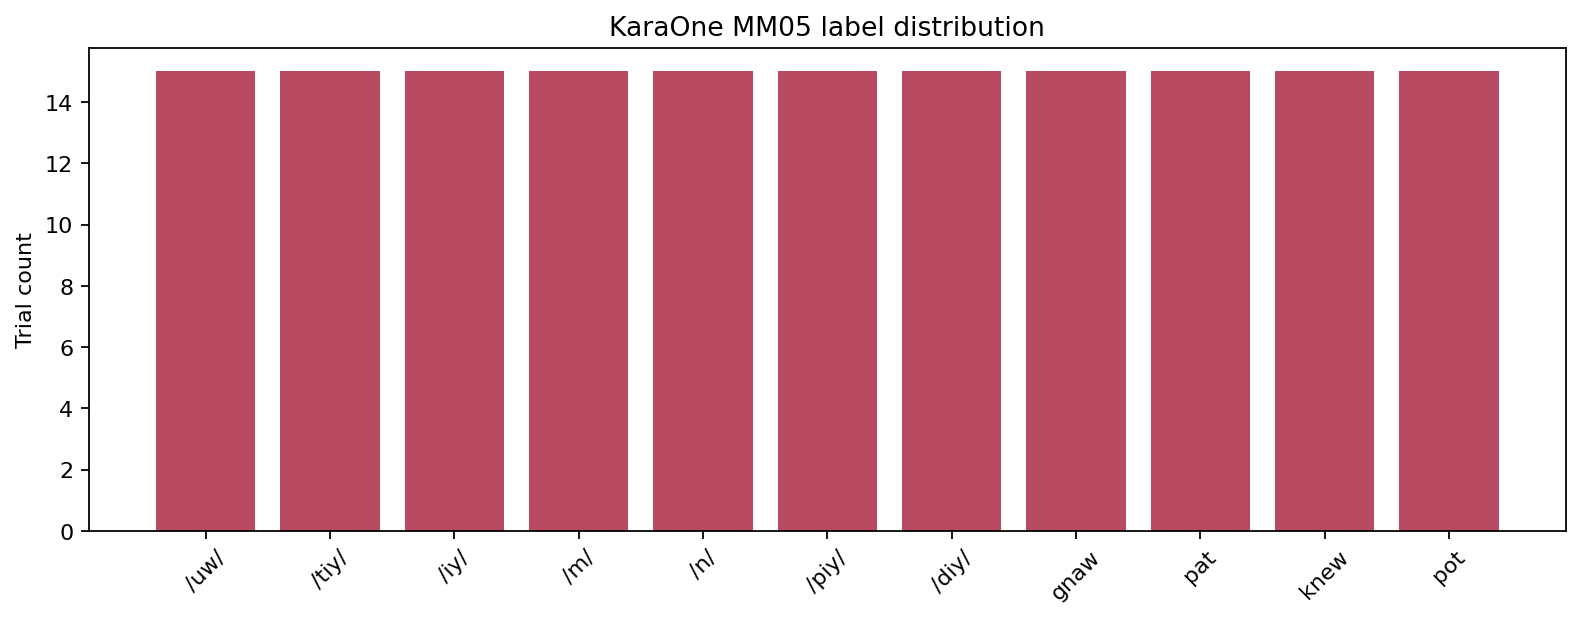

Trigger unique values observed via MNE: `[0.06553502048486844]`

In [8]:
label_df = pd.DataFrame(sorted(summary['representative_label_counter'].items()), columns=['label', 'count'])
display(label_df)
display(Image(filename=assets['labels']))
display(Markdown(f"Trigger unique values observed via MNE: `{summary['trigger_unique_values']}`"))


## 五、与研究目标的匹配度评估

In [9]:
fit_df = pd.DataFrame(summary['research_fit'].items(), columns=['task', 'judgment'])
display(fit_df)
for note in summary['data_quality_notes']:
    print('-', note)

print('\nKey conclusion: KaraOne is materially better than FEIS for overt-to-imagined transfer and for overt EEG -> acoustic representation studies, but it is still a small-vocabulary dataset.')


,task,judgment
0,phoneme_classification,Yes - strong fit at phonological/syllabic prom...
1,word_classification,Moderate - includes four words but vocabulary ...
2,speech_decoding,Yes - better than FEIS because EEG/audio/face ...
3,speech_reconstruction,Moderate foundation only


- epoch_inds.mat 是真正可用于 trial 对齐的关键信息源；MNE 读出的 Trigger 通道基本为常数，不能直接拿来做事件恢复。
- 单受试者同时具备原始 EEG、预处理特征、overt audio、face animation units，模态丰富度明显强于 FEIS。
- speaking_inds 数量是 330，而 labels 只有 165；数据自身显示每个 trial 对应两个 speaking-like 片段，较短者接近刺激呈现，较长者更像 overt speaking。

Key conclusion: KaraOne is materially better than FEIS for overt-to-imagined transfer and for overt EEG -> acoustic representation studies, but it is still a small-vocabulary dataset.


## 六、处理后数据分析

5秒 Rest 放空，不想任何内容
Stimulus State 屏幕显示一个 prompt（例如 iy、uw、pat、pot 等），同时播放对应的语音音频，然后给受试者 2秒时间摆好发音口型
5秒 Imagined Speech，想象说出这个 prompt，不能实际发声
Speaking State，真正把 prompt 说出来，Kinect 记录音频和面部动作

In [10]:
# Cell 1: 加载数据
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/processed/thinking_waveform_pairs/karaone/subjects/MM05.npz"
data = np.load(path, allow_pickle=True)

print(data.files)

['trial_indices', 'labels', 'audio_relpaths', 'channel_names', 'eeg_sfreq_hz', 'stage_names', 'stage__clearing', 'stage__clearing__valid_lengths', 'stage__clearing__src_ranges', 'stage__stimulus_like', 'stage__stimulus_like__valid_lengths', 'stage__stimulus_like__src_ranges', 'stage__thinking', 'stage__thinking__valid_lengths', 'stage__thinking__src_ranges', 'stage__overt_like', 'stage__overt_like__valid_lengths', 'stage__overt_like__src_ranges']


In [11]:
# Cell 2: 读取基础字段
trial_indices = data["trial_indices"]
labels = data["labels"]
audio_relpaths = data["audio_relpaths"]
channel_names = data["channel_names"]
sfreq = int(data["eeg_sfreq_hz"][0])
stage_names = data["stage_names"]

print("trial 数:", len(trial_indices))
print("channel 数:", len(channel_names))
print("采样率:", sfreq)
print("阶段:", stage_names.tolist())

trial 数: 165
channel 数: 62
采样率: 256
阶段: ['clearing', 'stimulus_like', 'thinking', 'overt_like']


In [12]:
# Cell 3: 各 stage 的 shape / 长度统计
summary_rows = []

for stage in stage_names:
    x = data[f"stage__{stage}"]
    valid_lengths = data[f"stage__{stage}__valid_lengths"]
    src_ranges = data[f"stage__{stage}__src_ranges"]

    summary_rows.append({
        "stage": stage,
        "shape": x.shape,
        "dtype": str(x.dtype),
        "valid_len_min": int(valid_lengths.min()),
        "valid_len_max": int(valid_lengths.max()),
        "valid_len_mean": float(valid_lengths.mean()),
        "duration_sec_mean": float(valid_lengths.mean() / sfreq),
        "src_range_shape": src_ranges.shape,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,stage,shape,dtype,valid_len_min,valid_len_max,valid_len_mean,duration_sec_mean,src_range_shape
0,clearing,"(165, 62, 1277)",float32,1267,1277,1274.800000,4.979687,"(165, 2)"
1,stimulus_like,"(165, 62, 518)",float32,509,518,514.527273,2.009872,"(165, 2)"
2,thinking,"(165, 62, 1272)",float32,1258,1272,1267.442424,4.950947,"(165, 2)"
3,overt_like,"(165, 62, 718)",float32,431,718,575.000000,2.246094,"(165, 2)"


In [13]:
# Cell 4: 标签分布
label_counts = pd.Series(labels).value_counts().sort_index()
label_counts.to_frame("count")

,count
/diy/,15
/iy/,15
/m/,15
/n/,15
/piy/,15
/tiy/,15
/uw/,15
gnaw,15
knew,15
pat,15


In [14]:
# Cell 5: trial 元信息预览
meta_df = pd.DataFrame({
    "trial_index": trial_indices,
    "label": labels,
    "audio_relpath": audio_relpaths,
})

meta_df.head(10)

,trial_index,label,audio_relpath
0,0,/uw/,audio/MM05/000.wav
1,1,/tiy/,audio/MM05/001.wav
2,2,/tiy/,audio/MM05/002.wav
3,3,/uw/,audio/MM05/003.wav
4,4,/iy/,audio/MM05/004.wav
5,5,/m/,audio/MM05/005.wav
6,6,/n/,audio/MM05/006.wav
7,7,/iy/,audio/MM05/007.wav
8,8,/n/,audio/MM05/008.wav
9,9,/piy/,audio/MM05/009.wav


In [15]:
# Cell 6: 每个 stage 的全局统计
for stage in stage_names:
    x = data[f"stage__{stage}"]
    valid_lengths = data[f"stage__{stage}__valid_lengths"]

    print(f"\n=== {stage} ===")
    print("shape:", x.shape)
    print("valid lengths 前10个:", valid_lengths[:10].tolist())
    print("global mean:", float(x.mean()))
    print("global std:", float(x.std()))
    print("global min:", float(x.min()))
    print("global max:", float(x.max()))


=== clearing ===
shape: (165, 62, 1277)
valid lengths 前10个: [1271, 1276, 1276, 1277, 1268, 1277, 1276, 1277, 1272, 1272]
global mean: -2.482061084441156e-11
global std: 1.0
global min: -18.558996200561523
global max: 17.70371437072754

=== stimulus_like ===
shape: (165, 62, 518)
valid lengths 前10个: [514, 514, 514, 514, 518, 514, 514, 518, 510, 518]
global mean: -0.00045575035619549453
global std: 1.0992430448532104
global min: -39.61273193359375
global max: 40.36467361450195

=== thinking ===
shape: (165, 62, 1272)
valid lengths 前10个: [1272, 1272, 1265, 1269, 1269, 1269, 1269, 1268, 1272, 1263]
global mean: -0.0005095894448459148
global std: 0.9088134169578552
global min: -45.85590362548828
global max: 58.77180862426758

=== overt_like ===
shape: (165, 62, 718)
valid lengths 前10个: [641, 718, 616, 607, 516, 667, 495, 521, 700, 692]
global mean: 0.00223153131082654
global std: 1.0379408597946167
global min: -39.8237190246582
global max: 28.4097957611084


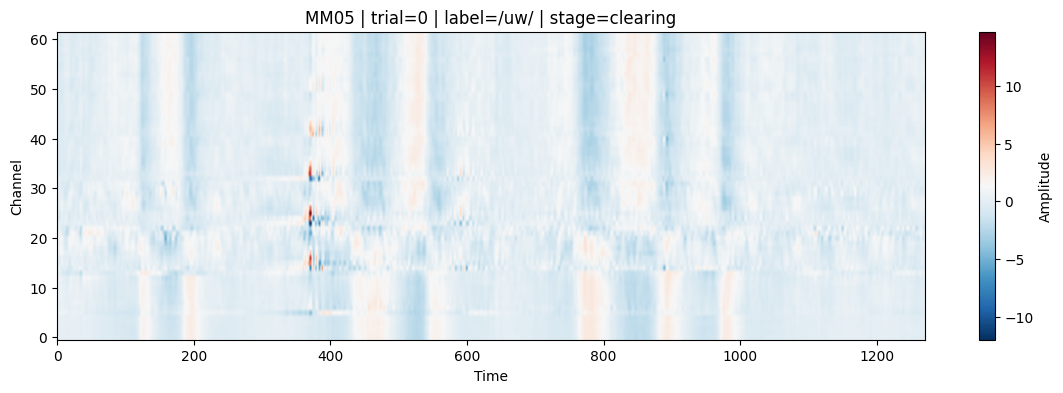

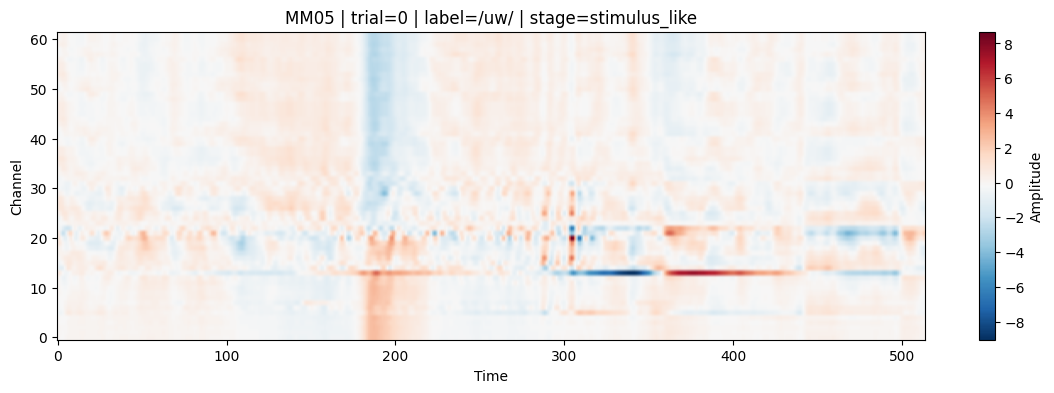

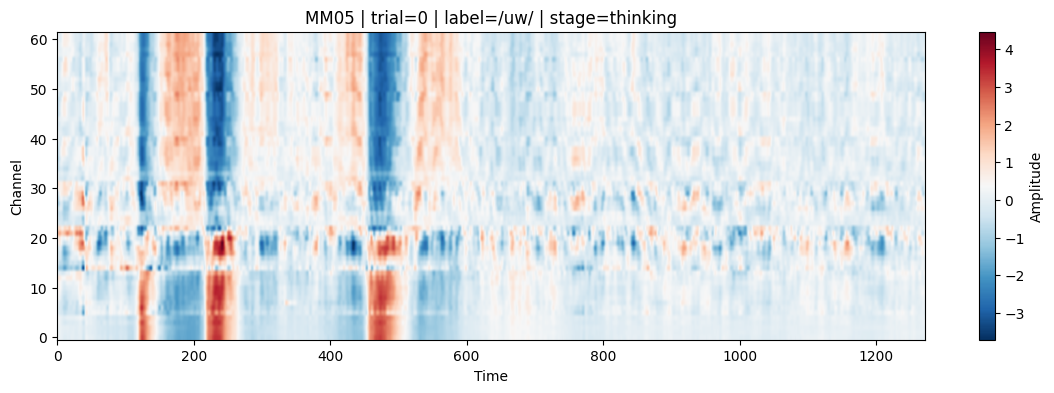

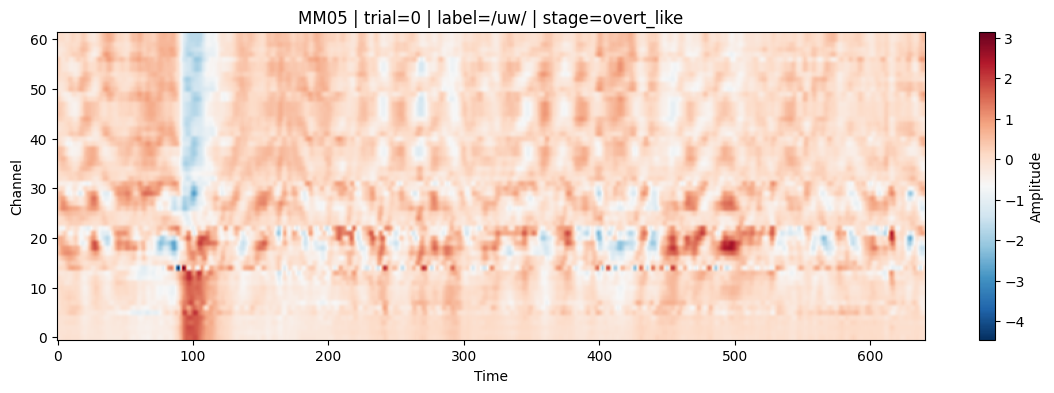

In [19]:
# Cell 1
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# 看一个 trial 的热力图
example_trial = 0
for stage in stage_names:
    x = data[f"stage__{stage}"]
    valid_len = int(
        data[f"stage__{stage}__valid_lengths"][example_trial]
    )
    plt.figure(figsize=(14, 4))
    im = plt.imshow(
        x[example_trial, :, :valid_len],
        aspect="auto",
        origin="lower",
        cmap="RdBu_r"
    )

    plt.colorbar(im, label="Amplitude")
    plt.title(
        f"MM05 | trial={example_trial} | "
        f"label={labels[example_trial]} | "
        f"stage={stage}"
    )
    plt.xlabel("Time")
    plt.ylabel("Channel")

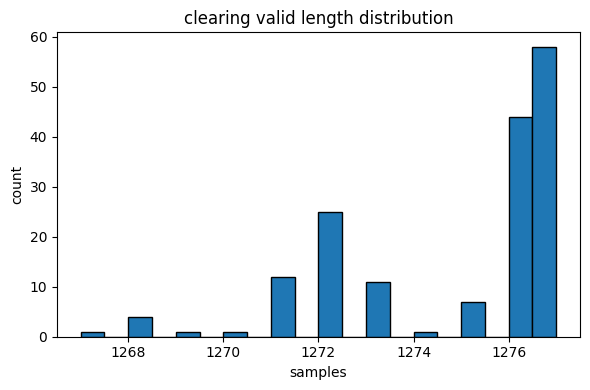

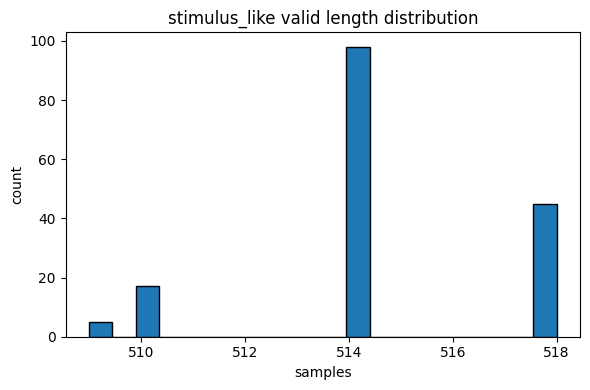

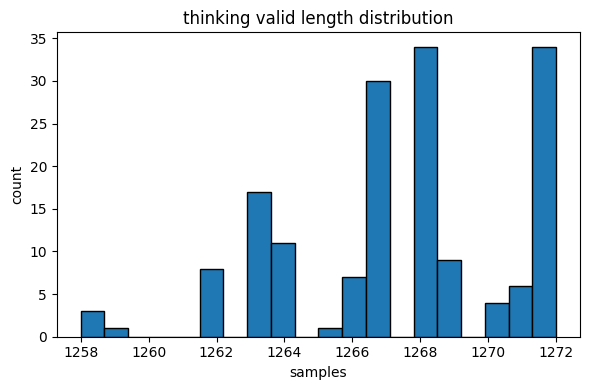

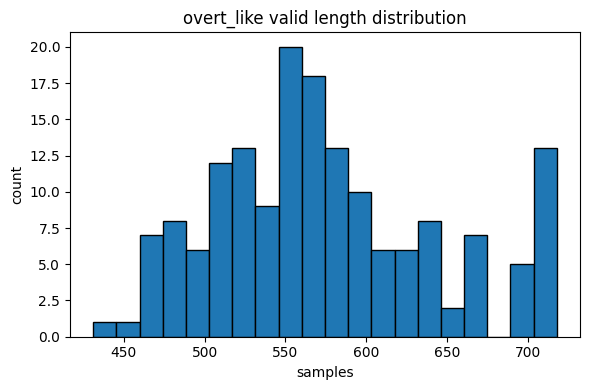

In [20]:
# Cell 8: 每个 stage 的 valid length 分布
for stage in stage_names:
    valid_lengths = data[f"stage__{stage}__valid_lengths"]

    plt.figure(figsize=(6, 4))
    plt.hist(valid_lengths, bins=20, edgecolor="black")
    plt.title(f"{stage} valid length distribution")
    plt.xlabel("samples")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

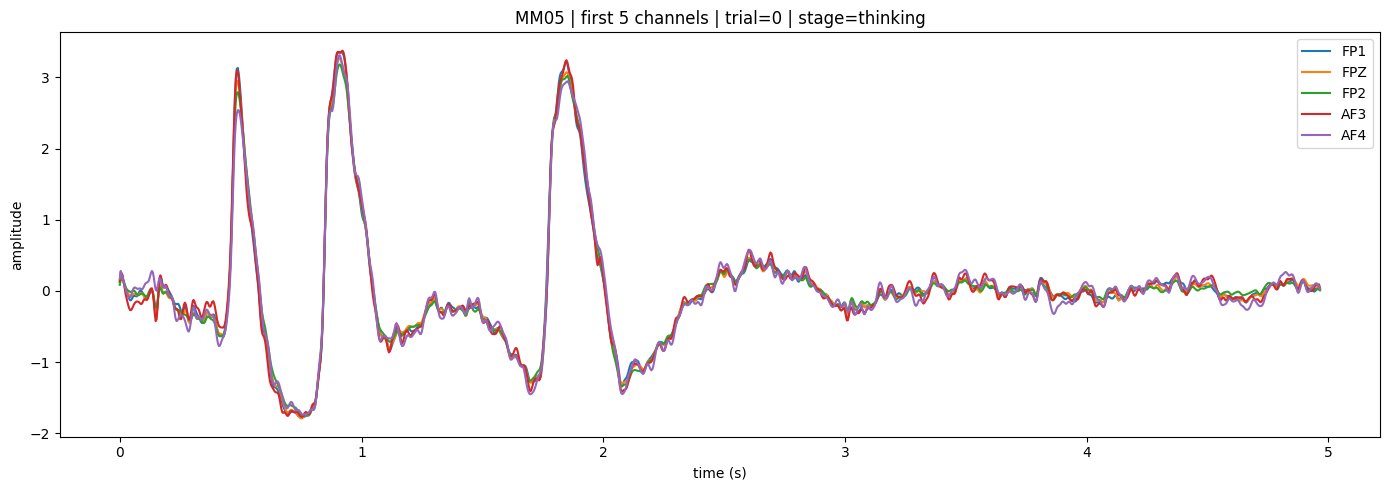

In [23]:
# Cell 9: 以 thinking 阶段为例，画前 5 个通道波形
stage = "thinking"
x = data[f"stage__{stage}"]
valid_len = int(data[f"stage__{stage}__valid_lengths"][example_trial])
time_axis = np.arange(valid_len) / sfreq

plt.figure(figsize=(14, 5))
for ch in range(min(5, x.shape[1])):
    plt.plot(time_axis, x[example_trial, ch, :valid_len], label=channel_names[ch])

plt.title(f"MM05 | first 5 channels | trial={example_trial} | stage={stage}")
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.legend()
plt.tight_layout()
plt.show()

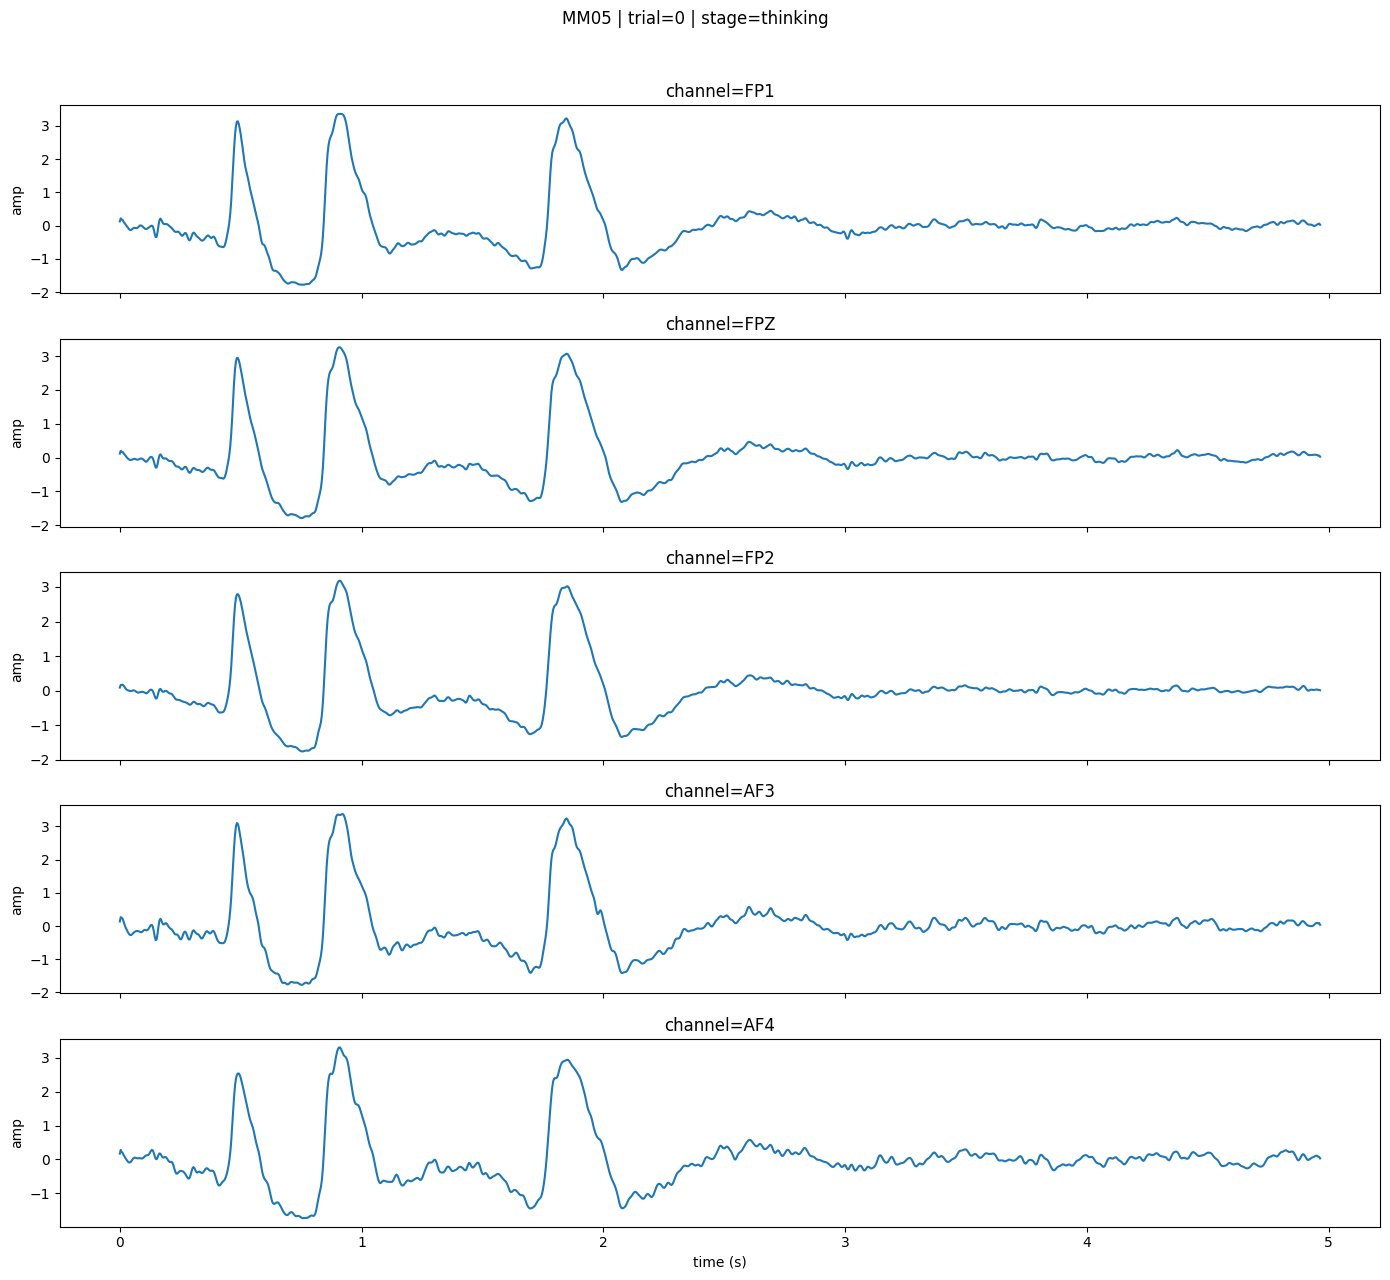

In [24]:
# Cell 9: 以 thinking 阶段为例，前 5 个通道画成 5 行子图
stage = "thinking"
x = data[f"stage__{stage}"]
valid_len = int(data[f"stage__{stage}__valid_lengths"][example_trial])
time_axis = np.arange(valid_len) / sfreq

n_ch = min(5, x.shape[1])
fig, axes = plt.subplots(n_ch, 1, figsize=(14, 2.5 * n_ch), sharex=True)

if n_ch == 1:
    axes = [axes]

for ch, ax in enumerate(axes):
    ax.plot(time_axis, x[example_trial, ch, :valid_len])
    ax.set_title(f"channel={channel_names[ch]}")
    ax.set_ylabel("amp")

axes[-1].set_xlabel("time (s)")
fig.suptitle(f"MM05 | trial={example_trial} | stage={stage}", y=1.02)
plt.tight_layout()
plt.show()